    team_id  market_value_eur  market_value_millions      team_name fifa_code
28       29        2134173029            2134.173029          Spain       ESP
32       33        1546204469            1546.204469         France       FRA
44       45        1321818896            1321.818896        England       ENG
40       41        1145908765            1145.908765       Portugal       POR
36       37        1025039444            1025.039444      Argentina       ARG
16       17         988741629             988.741629        Germany       GER
8         9         893232413             893.232413         Brazil       BRA
20       21         765217546             765.217546    Netherlands       NED
24       25         634065971             634.065971        Belgium       BEL
18       19         494766342             494.766342  Côte d'Ivoire       CIV
    team_id  market_value_eur  market_value_millions  team_name fifa_code  \
0        29        2134173029            2134.173029      Spain  

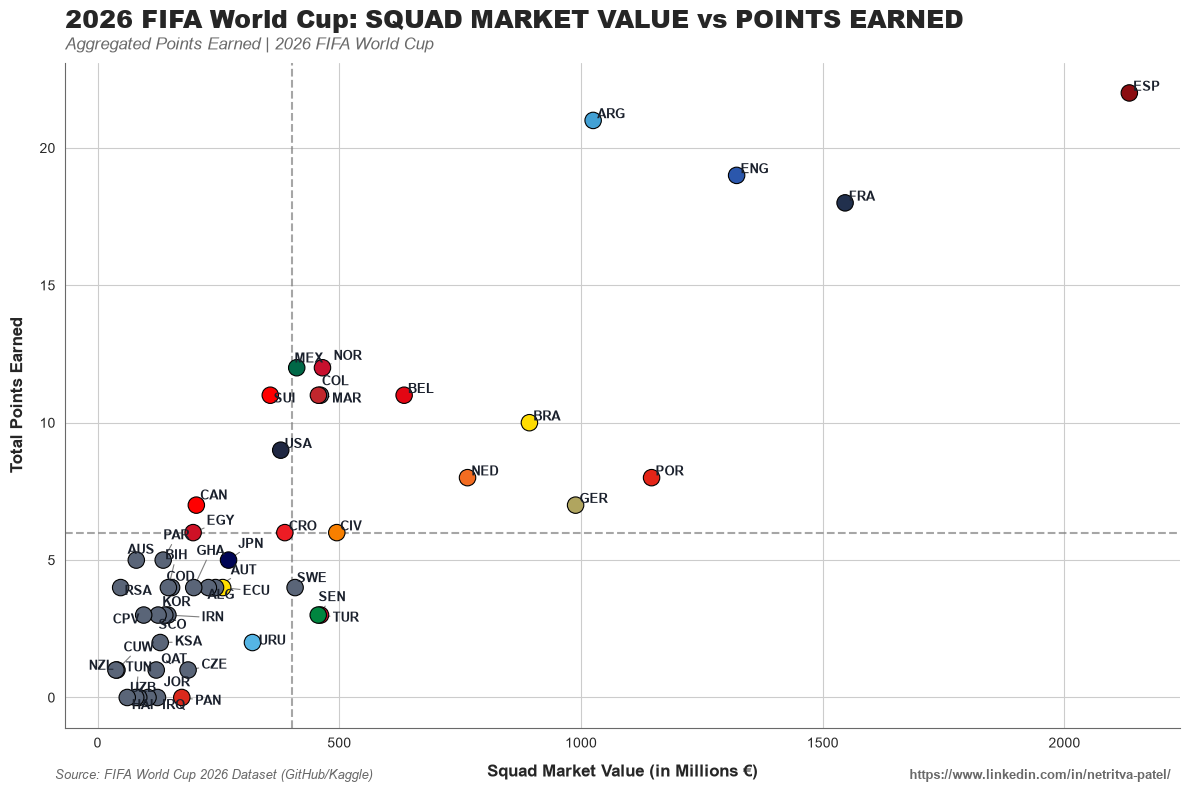

In [69]:
!pip install adjustText

from typing import final

import pandas as pd

# Load the Dataset
players_df = pd.read_csv('D:/archive/squads_and_players.csv')
teams_df = pd.read_csv('D:/archive/teams.csv')

# Group the team to get total market value of each team
# We divide by 1,000,000 to make the graph labels cleaner (e.g., "€500M" instead of 500000000)
squad_values  =players_df.groupby('team_id')['market_value_eur'].sum().reset_index()
squad_values['market_value_millions'] = squad_values['market_value_eur']/1000000

# Merge with the teams dataframe to get team names to get actual country names
team_value_df = pd.merge(squad_values, teams_df[['team_id','team_name','fifa_code']], on = 'team_id')

# Sort to see the most expensive teams
team_value_df = team_value_df.sort_values(by='market_value_millions', ascending=False)
print(team_value_df.head(10))

# Load the match data
matches_df = pd.read_csv('D:/archive/matches.csv')

# Calculate point for 'Home' teams
home_stats =matches_df[['home_team_id', 'home_score', 'away_score']].rename(columns={'home_team_id': 'team_id'})
home_stats['points'] =0
home_stats.loc[home_stats['home_score']>home_stats['away_score'], 'points'] = 3
home_stats.loc[home_stats['home_score']==home_stats['away_score'], 'points'] = 1

# Calculate point for 'Away' teams
away_stats = matches_df[['away_team_id', 'away_score', 'home_score']].rename(columns={'away_team_id': 'team_id'})
away_stats['points'] = 0
away_stats.loc[away_stats['away_score'] > away_stats['home_score'], 'points'] = 3
away_stats.loc[away_stats['away_score'] == away_stats['home_score'], 'points'] = 1

# Combine the home and away stats and sum the total points for each team
all_match_stats = pd.concat([
    home_stats[['team_id', 'points']],
    away_stats[['team_id', 'points']]
])

team_performance = all_match_stats.groupby('team_id')['points'].sum().reset_index()

# Merge the points data with our the Phase 1  data(Squad Values)

final_df = pd.merge(team_value_df, team_performance, on='team_id')
print(final_df.sort_values(by='points', ascending=False).head())

# Phase 3
import matplotlib.pyplot as plt
import seaborn as sns
from adjustText import adjust_text

# Define the colors for countries

team_colors ={
    'ESP': '#8B0D11', # Spain Red
    'ARG': '#43A1D5', # Argentina Sky Blue
    'FRA': '#21304D', # France Dark Blue
    'ENG': '#2B57AC', # England Dark Blue
    'BRA': '#FFDC02', # Brazil Yellow
    'GER': '#B0A55F', # Germany Gold
    'POR': '#E42518', # Portugal Red
    'NED': '#F36C21', # Netherlands Orange
    'BEL': '#E30613', # Belgium Red
    'MEX': '#006847', # Mexico Green
    'NOR': '#C8102E', # Norway Red
    'MAR': '#C1272D', # Morocco Red
    'USA': '#1F2742', # United States Blue
    'SUI': '#FF0000', # Switzerland Red
    'CAN': '#FF0000', # Canada Red
    'JPN': '#000555', # Japan Blue
    'CRO': '#ED1C24', # Croatia Red
    'URU': '#55B5E5', # Uruguay Light Blue
    'CIV': '#F77F00', # Côte d'Ivoire Orange
    'EGY': '#CE1126', # Egypt Red
    'SEN': '#00853F', # Senegal Green
    'ECU': '#FFDD00', # Ecuador Yellow
    'PAN': '#DA291C',  # Panama Red
    'TUR': '#C8102E',
}

# Assign the colors, defaulting to a sleek grey for unmapped teams
final_df['color'] = final_df['fifa_code'].map(team_colors).fillna('#5A6578')

# Set Style
plt.figure(figsize=(12, 8))
sns.set_style('whitegrid')

# Create the scatter plot
plt.scatter(
    final_df['market_value_millions'],
    final_df['points'],
    c = final_df['color'],
    s = 140,
    edgecolor='black',
    linewidth=0.8,
    zorder=3
)

# Calculate the averages for the quadrant axes
mean_val = final_df['market_value_millions'].mean()
mean_pts = final_df['points'].mean()

# Draw the quadrant lines
plt.axvline(x=mean_val, color ='gray', linestyle='--', alpha=0.7,zorder = 1)
plt.axhline(y=mean_pts, color ='gray', linestyle='--', alpha=0.7,zorder = 1)

# Add text labels and smartly adjust positions

texts =[]
for i in range(len(final_df)):
    texts.append(
        plt.text(
            final_df['market_value_millions'].iloc[i],
                    final_df['points'].iloc[i],
                    final_df['fifa_code'].iloc[i],
                    fontsize=9.5,
                    weight='bold',
                    color = '#1A202C'
        )
        
    )


# Repel labels to avoid overlap
adjust_text(
    texts,
    arrowprops=dict(arrowstyle='-', color='gray', lw=0.8, alpha=1)
)
# Set the title and labels
ax = plt.gca()

# Hide the top and right spines completely
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Make the bottom and left spines match the sleek grey of your subtitle
ax.spines['bottom'].set_color('dimgrey')
ax.spines['left'].set_color('dimgrey')

#Subtitle: Italicized, Grey, placed just below the main title using axes coordinates
ax.text(0, 1.02, 'Aggregated Points Earned | 2026 FIFA World Cup', 
        transform=ax.transAxes, 
        fontsize=12, 
        fontstyle='italic', 
        color='dimgrey')

plt.title('2026 FIFA World Cup: SQUAD MARKET VALUE vs POINTS EARNED', fontsize=18, weight='black',pad = 25, loc ='left')
plt.xlabel('Squad Market Value (in Millions €)', fontsize=12, weight = 'bold', labelpad=10)
plt.ylabel('Total Points Earned', fontsize=12, weight = 'bold', labelpad=10)\

# 7. Footer: Data Sources and Personal Watermark
# Left-aligned source credit
plt.figtext(0.05, 0.02, 'Source: FIFA World Cup 2026 Dataset (GitHub/Kaggle)', 
            ha='left', fontsize=9, color='dimgrey', fontstyle='italic')

# Right-aligned personal watermark
plt.figtext(0.98, 0.02, 'https://www.linkedin.com/in/netritva-patel/', 
            ha='right', fontsize=9, color='dimgrey', weight='bold')
plt.tight_layout()
plt.savefig('D:/Football_Data/Second_Project/market_value_vs_points.png', dpi=450, bbox_inches='tight')
plt.show()